# 05 — Analisis Katalog Netflix

Berapa banyak film vs serial TV di Netflix? Genre apa yang paling banyak? Negara mana yang paling produktif? Pada proyek ini kita menganalisis **katalog Netflix** dan sekaligus belajar **operasi teks (string)** serta **parsing tanggal**.

> 🎯 **Tujuan Pembelajaran**
> - Membandingkan kategori (`Movie` vs `TV Show`).
> - Mem-parsing tanggal dari teks (`date_added`) untuk menganalisis tren per tahun.
> - Memecah kolom multi-nilai (`listed_in`) untuk menghitung genre populer.
> - Operasi string dasar pada pandas (`.str`).
> - Memvisualisasikan distribusi tipe, tren, negara, dan genre.

**Tingkat:** Pemula–Menengah • **Estimasi waktu:** 35 menit

## 📊 Tentang Dataset

Dataset berisi katalog **8.807 judul** (film & serial TV) yang tersedia di Netflix beserta
metadatanya.

- **Sumber:** [Kaggle — shivamb/netflix-shows](https://www.kaggle.com/datasets/shivamb/netflix-shows)
- **Jumlah data:** 8.807 baris × 12 kolom

| Kolom | Arti |
|-------|------|
| `type` | Movie atau TV Show |
| `title` | Judul |
| `country` | Negara produksi |
| `date_added` | Tanggal ditambahkan ke Netflix (teks) |
| `release_year` | Tahun rilis |
| `rating` | Rating usia (mis. TV-MA, PG-13) |
| `duration` | Durasi (menit / jumlah musim) |
| `listed_in` | Daftar genre (dipisah koma) |

Kita nantinya hanya akan memakai 8 kolom utama sebagai bahan eksplorasi dan latihan

## 1. Import Library

- **pandas** → olah tabel & teks. • **numpy** → angka. • **matplotlib**/**seaborn** → grafik.
- `Counter` dari `collections` → menghitung frekuensi genre.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [3]:
# Instal Kaggle
!pip install -q kaggle

# Pastikan file kaggle.json sudah di-upload ke Colab
# Jalankan perintah ini untuk mendownload dan unzip otomatis
!kaggle datasets download shivamb/netflix-shows

Dataset URL: https://www.kaggle.com/datasets/shivamb/netflix-shows
License(s): CC0-1.0
netflix-shows.zip: Skipping, found more recently modified local copy (use --force to force download)


In [4]:
#Unzip file dalam folder netfliz-shows
import zipfile

zip_file_path = 'netflix-shows.zip'
csv_file_in_zip = 'netflix_titles.csv'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    with zip_ref.open(csv_file_in_zip) as csv_file:
        df = pd.read_csv(csv_file)

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [6]:
print("Bentuk Data : ", df.shape )
print("Header : ", list(df.columns))

Bentuk Data :  (8807, 12)
Header :  ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


Interpretasi

Tiap baris berisi adalah 1 Judul Tayangan yang ada di platform netflix, mulai dari tipe, judul, director, artis, negara, tanggal ditambahkan ke platform, tahun release, Rating tayangan, durasi, genre dan deskripsi tayangan

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [9]:
#Cek missing value pada kolom yang dipakai
df[["type", "country", "date_added", "release_year", "rating", "listed_in"]].isnull().sum()

,0
type,0
country,831
date_added,10
release_year,0
rating,4
listed_in,0


Interpretasi

- ada beberapa missing value di kolom (Director, Cast, Country, date_added, duration dan rating)
-  Untuk pengolahan data kita hanya menggunakan data (tipe, country, date_added, release_year, rating, dan listied_in)

dengan kata lain kita akan melakukan penanganan dengan imputasi/menghapusnya terhadap data kolom (data_added dan rating)

## Pembersihan & Persiapan Data

Kita parsing `date_added` jadi datetime untuk mengambil **tahun penambahan**, dan rapikan spasi
pada teksnya.

In [13]:
#hapus spasi dan parsing tanggal
df['date_added']=df['date_added'].str.strip()


df['date_added_dt']=pd.to_datetime(df['date_added'], errors="coerce")
df['year_added']=df['date_added_dt'].dt.year

print("Contoh Hasil Parsing")
df[['title','date_added', 'date_added_dt', 'year_added']].head()

Contoh Hasil Parsing


,title,date_added,date_added_dt,year_added
0,Dick Johnson Is Dead,"September 25, 2021",2021-09-25,2021.0
1,Blood & Water,"September 24, 2021",2021-09-24,2021.0
2,Ganglands,"September 24, 2021",2021-09-24,2021.0
3,Jailbirds New Orleans,"September 24, 2021",2021-09-24,2021.0
4,Kota Factory,"September 24, 2021",2021-09-24,2021.0


In [15]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   show_id        8807 non-null   object        
 1   type           8807 non-null   object        
 2   title          8807 non-null   object        
 3   director       6173 non-null   object        
 4   cast           7982 non-null   object        
 5   country        7976 non-null   object        
 6   date_added     8797 non-null   object        
 7   release_year   8807 non-null   int64         
 8   rating         8803 non-null   object        
 9   duration       8804 non-null   object        
 10  listed_in      8807 non-null   object        
 11  description    8807 non-null   object        
 12  date_added_dt  8797 non-null   datetime64[ns]
 13  year_added     8797 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(11)
memory usage: 963

Interpretasi

Kolom Teks 'date_added' sudah berhasil diubah menjadi 'date_added_in' dan 'year_added'



## EDA & Visualisasi

### a) Movie vs TV Show (countplot)

/tmp/ipykernel_5451/3638096496.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='type', data=df,  palette="Set2")


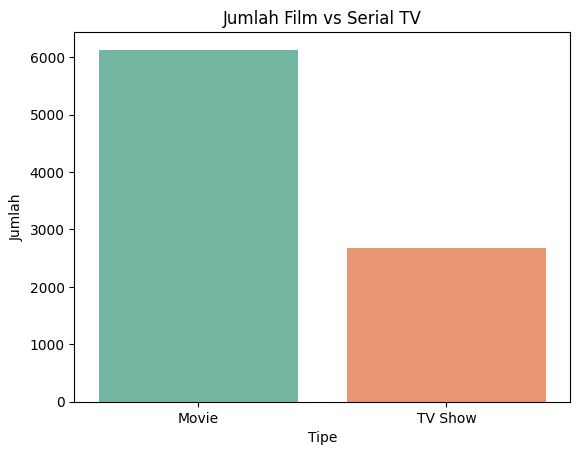

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [22]:
# Movie vs TV Show
sns.countplot(x='type', data=df,  palette="Set2")
plt.title('Jumlah Film vs Serial TV')
plt.xlabel('Tipe')
plt.ylabel('Jumlah')
plt.show()

print(df['type'].value_counts())

Interpretasi

Film(Movie) jumlahnya lebih banya daripada TV Serial didalam Katalog Netflix, sekitar 2/3 isi katalog adalah Film

### b) Jumlah Film Berdasarkan tahun rilis

/tmp/ipykernel_5451/1517868130.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='release_year_cat', data=df,  palette="Set2")


Text(0, 0.5, 'Jumlah Film')

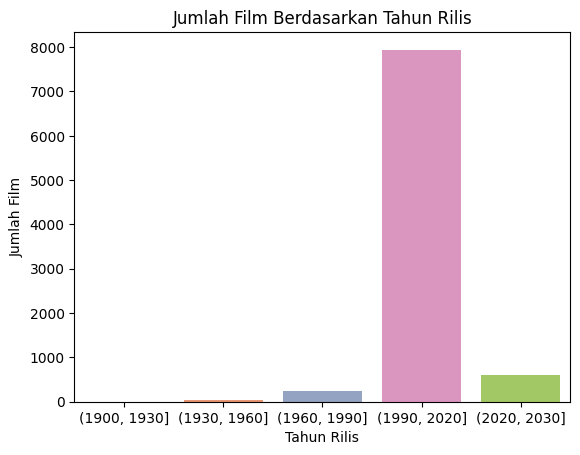

In [25]:
#Release year dikategorikan dulu
df['release_year_cat'] = pd.cut(df['release_year'], bins=[1900, 1930, 1960, 1990, 2020, 2030])

sns.countplot(x='release_year_cat', data=df,  palette="Set2")
plt.title('Jumlah Film Berdasarkan Tahun Rilis')
plt.xlabel('Tahun Rilis')
plt.ylabel('Jumlah Film')


Interpretasi

Film dan Serial TV yang tayang di katalog Netflix, yang mendominasi adalah Film dan Serial TV yang di release dari tahun 1990 s/d 2020, diikuti dengan Film terbaru di tahun 2020 s/d 2030

### c) Tren jumlah judul ditambahkan per tahun (line chart)

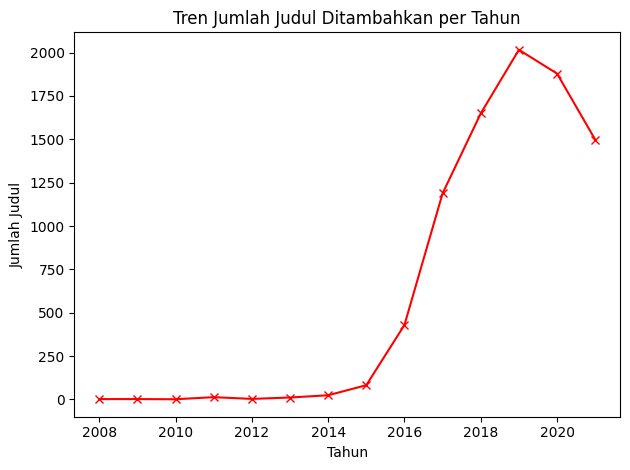

In [29]:
annualy = df.dropna(subset=['year_added']).groupby(df['year_added']).size()
annualy = annualy[annualy<=2021]
annualy.plot(marker="x", color="red")

plt.title('Tren Jumlah Judul Ditambahkan per Tahun')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Judul')
plt.tight_layout()
plt.show()

Interpretasi

Penambahan Konten secara masif terjadi mulai sekitar 2016 dan puncaknya 2019-2020, sejalan dengan ekspansi netflix secara global.

faktor x lain seperti pandemi memungkinkan kenaikan ini, dikarnakan banyaknya permintaan user yang menonton dan beraktivitas dari rumah

### d) 10 negara dengan konten terbanyak

Kolom `country` bisa berisi beberapa negara. Kita ambil **negara pertama** sebagai penyederhanaan, lalu hitung yang terbanyak.

/tmp/ipykernel_5451/3865960317.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10.values, y=top_10.index, palette="mako")


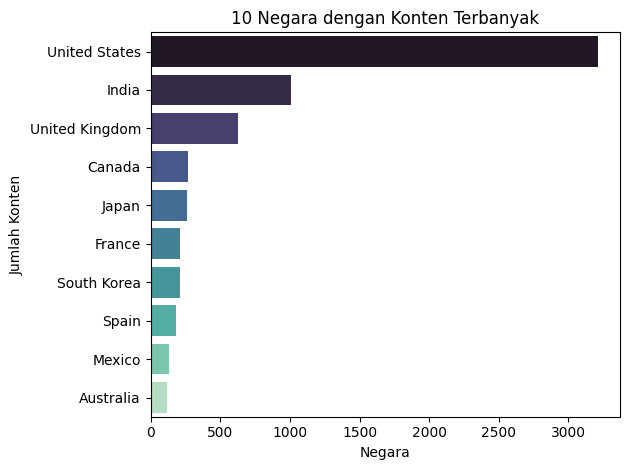

In [40]:
#10 top content
country = df["country"].dropna().str.split(", ").str[0]
top_10 = country.value_counts().head(10)


sns.barplot(x=top_10.values, y=top_10.index, palette="mako")
plt.title('10 Negara dengan Konten Terbanyak')
plt.xlabel('Negara')
plt.ylabel('Jumlah Konten')
plt.tight_layout()
plt.show()

Interpretasi

USA, India dan UK mendominasi dengan jumlah Konten terbanyak.
dengan artian target pasar di ketiga negara ini terbesar dan menjadi fokus target pasar netflix dan amerika mendominasi sebagai target pasar utama

### e) 10 Genre paling populer

Kolom `listed_in` berisi banyak genre per judul (dipisah koma). Kita pecah dan hitung frekuensi tiap genre memakai `Counter`.

In [36]:
all_genre = []

for baris in df['listed_in'].dropna():
    for genre in baris.split(','):
        all_genre.append(genre.strip())

In [37]:
genre_count = Counter(all_genre)
top10_genre = pd.Series(dict(genre_count.most_common(10)))

/tmp/ipykernel_5451/4122736698.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_genre.values, y=top10_genre.index, palette="mako")


Text(0, 0.5, 'Genre')

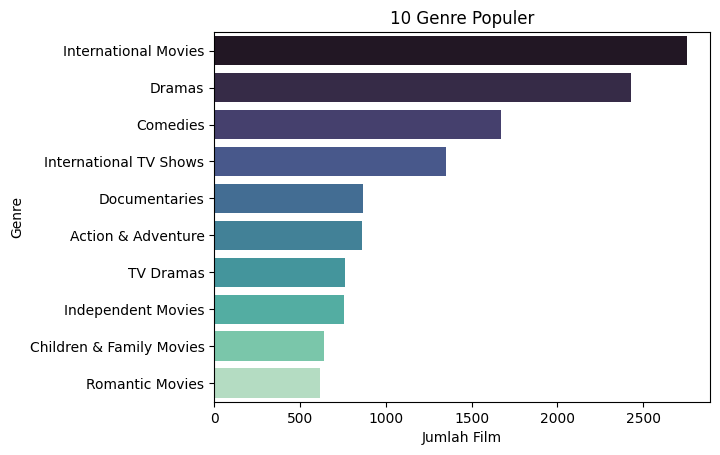

In [39]:
sns.barplot(x=top10_genre.values, y=top10_genre.index, palette="mako")
plt.title('10 Genre Populer')
plt.xlabel('Jumlah Film')
plt.ylabel('Genre')

Interpretasi

Genre Internasional Movie, Dramas, dan Comedies, Mendominasi Katalog Netflix,

Jelas Netflix menekankan konten Internasional untuk menjangkau seluruh pasar Global

### f) Distribusi Rating

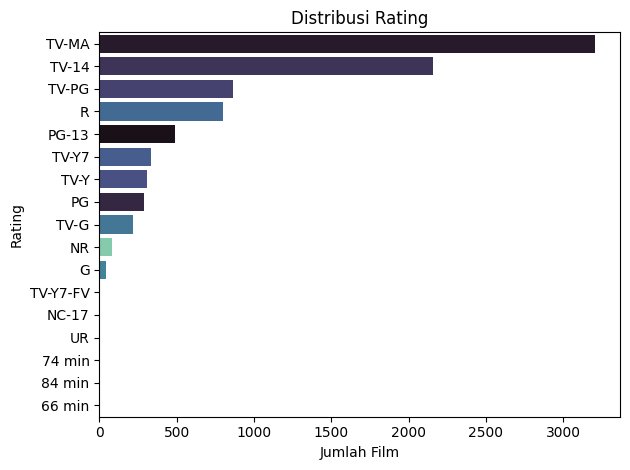

In [44]:
sns.countplot(y='rating', data=df, palette="mako", order=df['rating'].value_counts().index, hue='rating', legend=False)
plt.title('Distribusi Rating')
plt.xlabel('Jumlah Film')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()

## Kesimpulan & Insight

- Katalog Netflix didominasi **film** (~2/3) dibanding serial TV.
- Penambahan konten melonjak sejak **2016** dan memuncak 2019–2020.
- **Amerika Serikat** dan **India** adalah produsen konten terbanyak.
- Genre teratas: **International Movies, Dramas, Comedies** → strategi konten global.
- Keterampilan kunci: parsing tanggal dari teks, operasi `.str`, memecah kolom multi-nilai.

## 💼 Rekomendasi & Insight Bisnis

Dominasi **konten internasional & rilis terbaru** menunjukkan strategi Netflix menjangkau audiens global. Untuk tim konten/akuisisi, ini menyiratkan **peluang pada konten lokal** yang belum jenuh dan pentingnya menjaga aliran judul baru. Analisis katalog seperti ini juga membantu memetakan kekosongan genre untuk produksi original.

### ⚠️ Jebakan Data
- Kolom **multinilai** seperti `listed_in` (genre) dan `country` memuat banyak nilai per sel —   harus dipecah dengan `str.split(", ").explode()` sebelum dihitung, kalau tidak hitungannya salah.

- `date_added` berupa teks dengan format tak konsisten — parse memakai `pd.to_datetime(..., errors="coerce")`   agar nilai bermasalah jadi `NaT`, bukan menggagalkan seluruh proses.